### <CENTER> GOLD PURITY ESTIMATOR </CENTER>

#### Setup

In [141]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [142]:
IMAGE_PATH = "images/prototype/"

#### Volume Measurement - Prototype

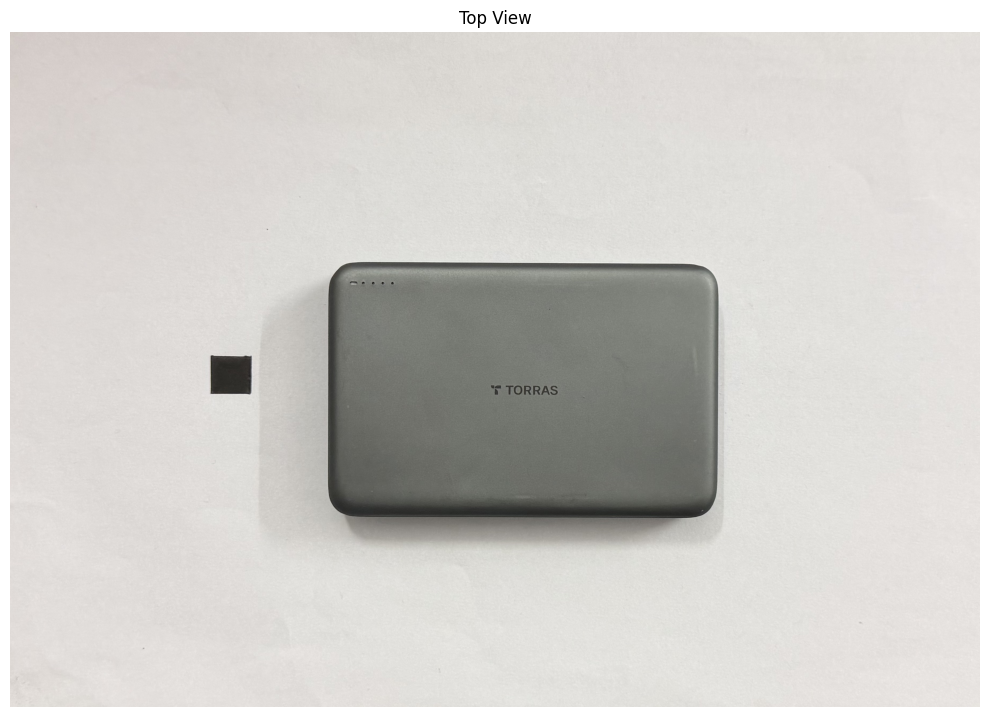

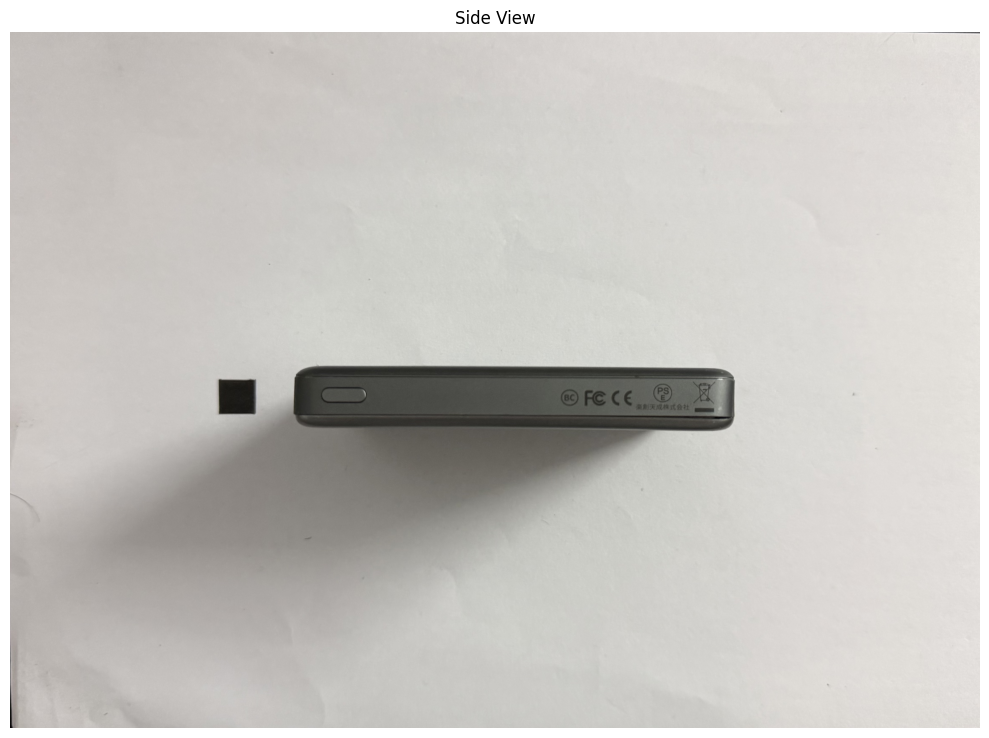

In [ ]:
# power bank
top_view_path = IMAGE_PATH + "IMG_0331.jpeg"
side_view_path = IMAGE_PATH + "IMG_0303.jpeg"

# ring
# top_view_path = IMAGE_PATH + "IMG_0326.jpeg"
# side_view_path = IMAGE_PATH + "IMG_0330.jpeg"

top_view = cv2.imread(top_view_path)
side_view = cv2.imread(side_view_path)

if top_view is None:
    print(f"Error: Could not load image from {top_view_path}")
    print("Note: OpenCV may not support HEIC format. Convert to JPG/PNG first.")
else:
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(top_view, cv2.COLOR_BGR2RGB))
    plt.title("Top View")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if side_view is None:
    print(f"Error: Could not load image from {side_view_path}")
    print("Note: OpenCV may not support HEIC format. Convert to JPG/PNG first.")
else:
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(side_view, cv2.COLOR_BGR2RGB))
    plt.title("Side View")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [144]:
def compute_scale_from_ref(img, real_size_cm=1.0, debug=True, threshold_value=120):
    """Estimate cm-per-pixel scale from a square reference marker.

    The function expects a dark square marker on a lighter background.
    Returns:
        scale (float): centimeters per pixel
        pixel_width (int): detected marker width in pixels
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY_INV)

    if debug:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(gray, cmap='gray')
        plt.title("Grayscale")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(thresh, cmap='gray')
        plt.title(f"Thresholded (t={threshold_value})")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area <= 500:
            continue

        approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)
        if len(approx) != 4:
            continue

        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = w / h if h != 0 else 0
        if not (0.8 <= aspect_ratio <= 1.2):
            continue

        pixel_width = w
        scale = real_size_cm / pixel_width

        if debug:
            img_vis = img.copy()
            cv2.rectangle(img_vis, (x, y), (x + w, y + h), (0, 255, 0), 3)
            cv2.putText(
                img_vis,
                f"Ref: {w}x{h} px | Scale: {scale:.6f} cm/px",
                (x, max(20, y - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                (0, 255, 0),
                2,
            )

            plt.figure(figsize=(10, 8))
            plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
            plt.title("Reference Square Detection")
            plt.axis('off')
            plt.tight_layout()
            plt.show()

        return scale, pixel_width

    raise ValueError("Square not detected. Try adjusting threshold_value.")

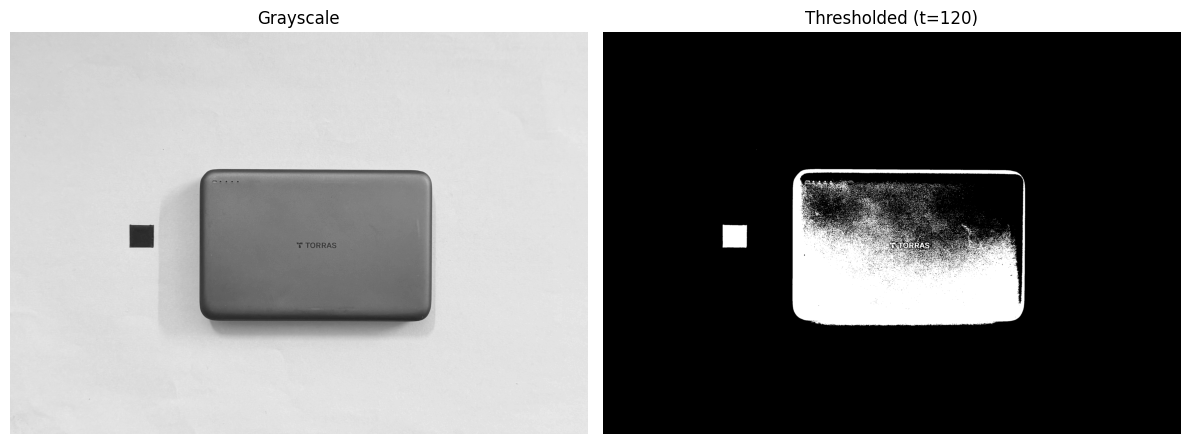

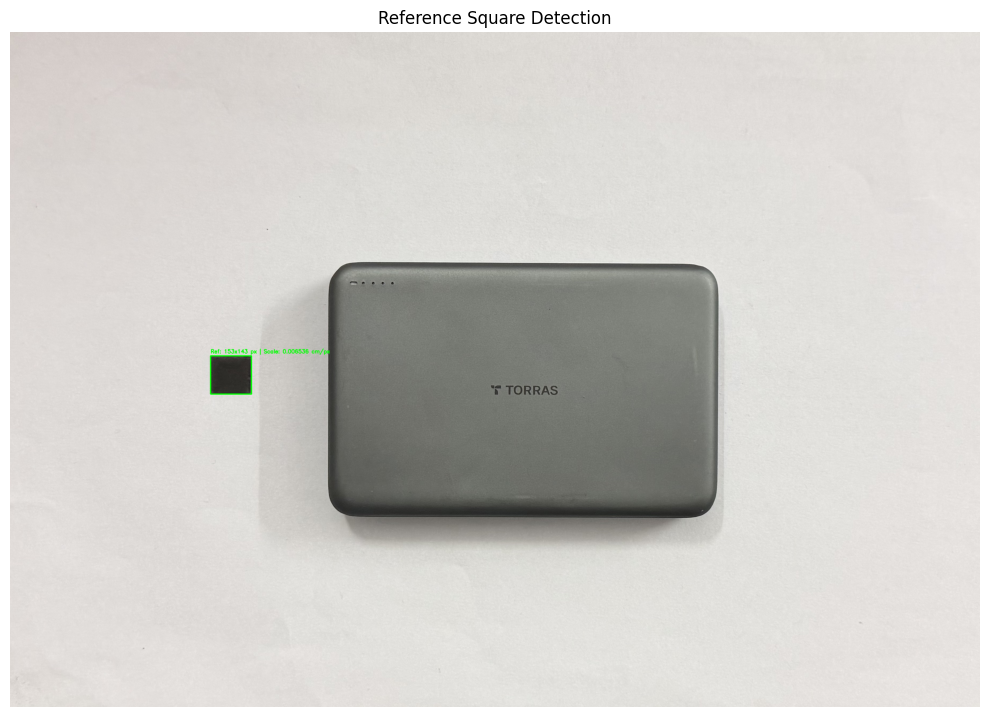

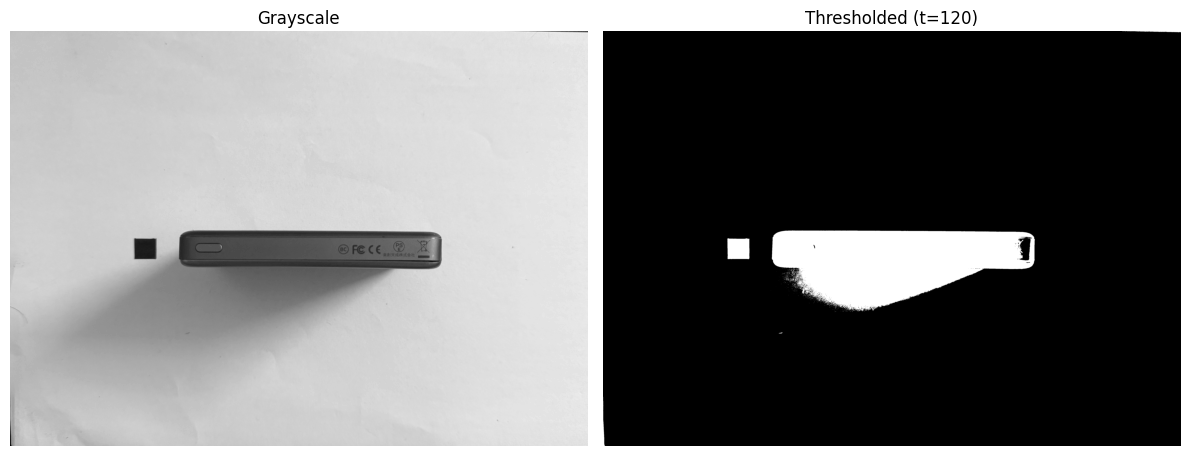

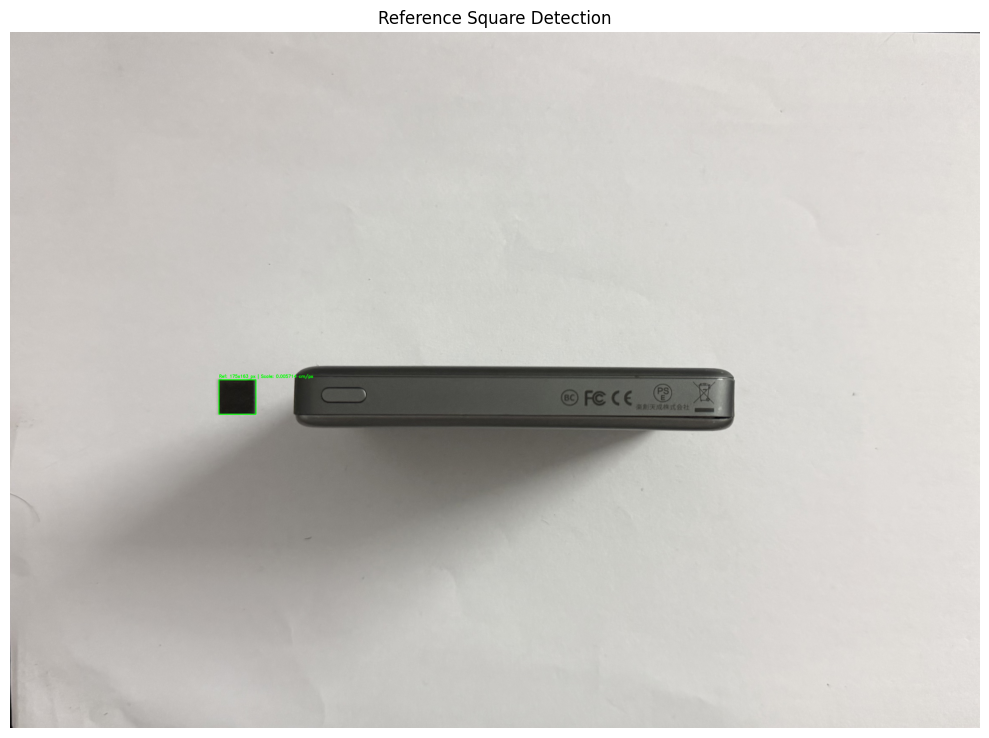

Top scale:  0.006536 cm/pixel
Side scale: 0.005714 cm/pixel
Scale mismatch (%): 13.41%


In [145]:
top_scale_cm, top_ref_size_px = compute_scale_from_ref(top_view, real_size_cm=1.0, debug=True)
side_scale_cm, side_ref_size_px = compute_scale_from_ref(side_view, real_size_cm=1.0, debug=True)

print(f"Top scale:  {top_scale_cm:.6f} cm/pixel")
print(f"Side scale: {side_scale_cm:.6f} cm/pixel")
print(f"Scale mismatch (%): {abs(top_scale_cm - side_scale_cm) / ((top_scale_cm + side_scale_cm)/2) * 100:.2f}%")

In [146]:
def segment_object(img, view_name="view", debug=True, ref_square_size_px=None, bg_similarity=0.80, 
                   close_iterations=2, edge_low=50, edge_high=150,):
    """Segment object material while preserving real through-holes.

    A candidate inner contour is considered a real hole only if its average
    brightness is close to the measured background brightness.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    edges = cv2.Canny(blur, edge_low, edge_high)
    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=close_iterations)

    contours, hierarchy = cv2.findContours(closed, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    if not contours or hierarchy is None:
        raise ValueError(f"No contours found for {view_name}.")

    hierarchy = hierarchy[0]
    external_indices = [i for i, h in enumerate(hierarchy) if h[3] == -1]
    if not external_indices:
        raise ValueError(f"No external contours found for {view_name}.")

    candidate_indices = []
    for i in external_indices:
        cnt = contours[i]
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / h if h != 0 else 0

        is_reference_square = False
        if ref_square_size_px is not None:
            size_tolerance = ref_square_size_px * 0.2
            if (
                abs(w - ref_square_size_px) < size_tolerance
                and abs(h - ref_square_size_px) < size_tolerance
                and 0.8 <= aspect_ratio <= 1.2
            ):
                is_reference_square = True

        if not is_reference_square:
            candidate_indices.append(i)

    if not candidate_indices:
        candidate_indices = external_indices

    obj_idx = max(candidate_indices, key=lambda idx: cv2.contourArea(contours[idx]))
    obj_contour = contours[obj_idx]

    outer_mask = np.zeros(gray.shape, dtype=np.uint8)
    cv2.drawContours(outer_mask, [obj_contour], -1, 255, -1)
    bg_mask = cv2.bitwise_not(outer_mask)
    bg_mean = cv2.mean(gray, mask=bg_mask)[0]

    mask = np.zeros(gray.shape, dtype=np.uint8)
    cv2.drawContours(mask, [obj_contour], -1, 255, -1)

    hole_contours = []
    for i, h in enumerate(hierarchy):
        if h[3] != obj_idx:
            continue

        inner_cnt = contours[i]
        inner_region_mask = np.zeros(gray.shape, dtype=np.uint8)
        cv2.drawContours(inner_region_mask, [inner_cnt], -1, 255, -1)
        inner_mean = cv2.mean(gray, mask=inner_region_mask)[0]
        ratio = inner_mean / bg_mean if bg_mean > 0 else 0

        if ratio >= bg_similarity:
            cv2.drawContours(mask, [inner_cnt], -1, 0, -1)
            hole_contours.append(inner_cnt)

    hull = cv2.convexHull(obj_contour)

    if debug:
        overlay = img.copy()
        cv2.drawContours(overlay, [obj_contour], -1, (0, 255, 255), 2)
        for hc in hole_contours:
            cv2.drawContours(overlay, [hc], -1, (255, 0, 255), 2)
        cv2.drawContours(overlay, [hull], -1, (0, 255, 0), 2)

        fig, axes = plt.subplots(1, 5, figsize=(26, 5))
        axes[0].imshow(gray, cmap='gray')
        axes[0].set_title(f"{view_name}: Grayscale")
        axes[0].axis('off')

        axes[1].imshow(edges, cmap='gray')
        axes[1].set_title(f"{view_name}: Edges")
        axes[1].axis('off')

        axes[2].imshow(closed, cmap='gray')
        axes[2].set_title(f"{view_name}: Closed")
        axes[2].axis('off')

        axes[3].imshow(mask, cmap='gray')
        axes[3].set_title(f"{view_name}: Material Mask")
        axes[3].axis('off')

        axes[4].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axes[4].set_title(f"{view_name}: Boundaries")
        axes[4].axis('off')

        plt.tight_layout()
        plt.show()

    return {
        "mask": mask,
        "contour": obj_contour,
        "holes": hole_contours,
        "hull": hull,
    }


def compute_volume_from_boundaries(top_seg, side_seg, top_scale_cm, side_scale_cm, debug=True):
    """Estimate object volume as top material area multiplied by side height."""
    top_mask = top_seg["mask"]
    side_mask = side_seg["mask"]

    top_area_px = cv2.countNonZero(top_mask)
    top_area_cm2 = top_area_px * (top_scale_cm ** 2)

    ys, xs = np.where(side_mask > 0)
    if len(ys) == 0:
        raise ValueError("No segmented pixels found in side view for height estimation.")

    y_min = int(np.min(ys))
    y_max = int(np.max(ys))
    side_height_px = y_max - y_min
    side_height_cm = side_height_px * side_scale_cm
    volume_cm3 = top_area_cm2 * side_height_cm

    print("--- Material-aware Measurement Transparency ---")
    print(f"Top material area used:  {top_area_px:.1f} px^2")
    print(f"Top material area used:  {top_area_cm2:.4f} cm^2")
    print(f"Side height used:        {side_height_px} px  |  {side_height_cm:.4f} cm")
    print(f"Volume = Area x Height:  {volume_cm3:.4f} cm^3")

    if debug:
        top_vis = cv2.cvtColor(top_mask, cv2.COLOR_GRAY2BGR)
        side_vis = cv2.cvtColor(side_mask, cv2.COLOR_GRAY2BGR)

        top_contours, top_hier = cv2.findContours(top_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
        if top_hier is not None:
            top_hier = top_hier[0]
            for i, c in enumerate(top_contours):
                color = (0, 255, 255) if top_hier[i][3] == -1 else (255, 0, 255)
                cv2.drawContours(top_vis, [c], -1, color, 2)

        xt, yt, wt, ht = cv2.boundingRect(top_seg["contour"])
        cv2.putText(top_vis, f"Area: {top_area_cm2:.2f} cm^2", (xt, max(yt - 10, 15)), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2,)

        x_med = int(np.median(xs))
        cv2.line(side_vis, (x_med, y_min), (x_med, y_max), (0, 0, 255), 2)
        cv2.putText(side_vis, f"Height: {side_height_cm:.2f} cm", (x_med + 8, y_min + 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2,)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        axes[0].imshow(cv2.cvtColor(top_vis, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Top View")
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(side_vis, cv2.COLOR_BGR2RGB))
        axes[1].set_title("Side View")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    return volume_cm3

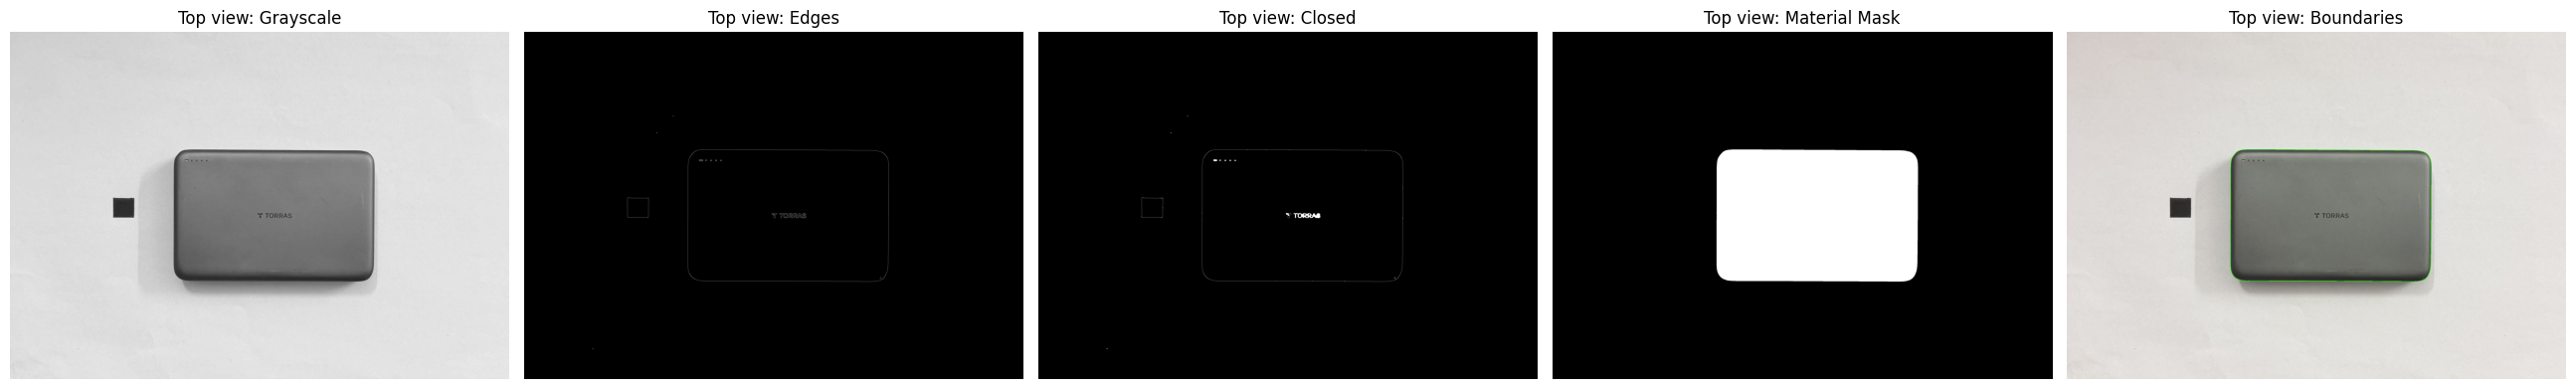

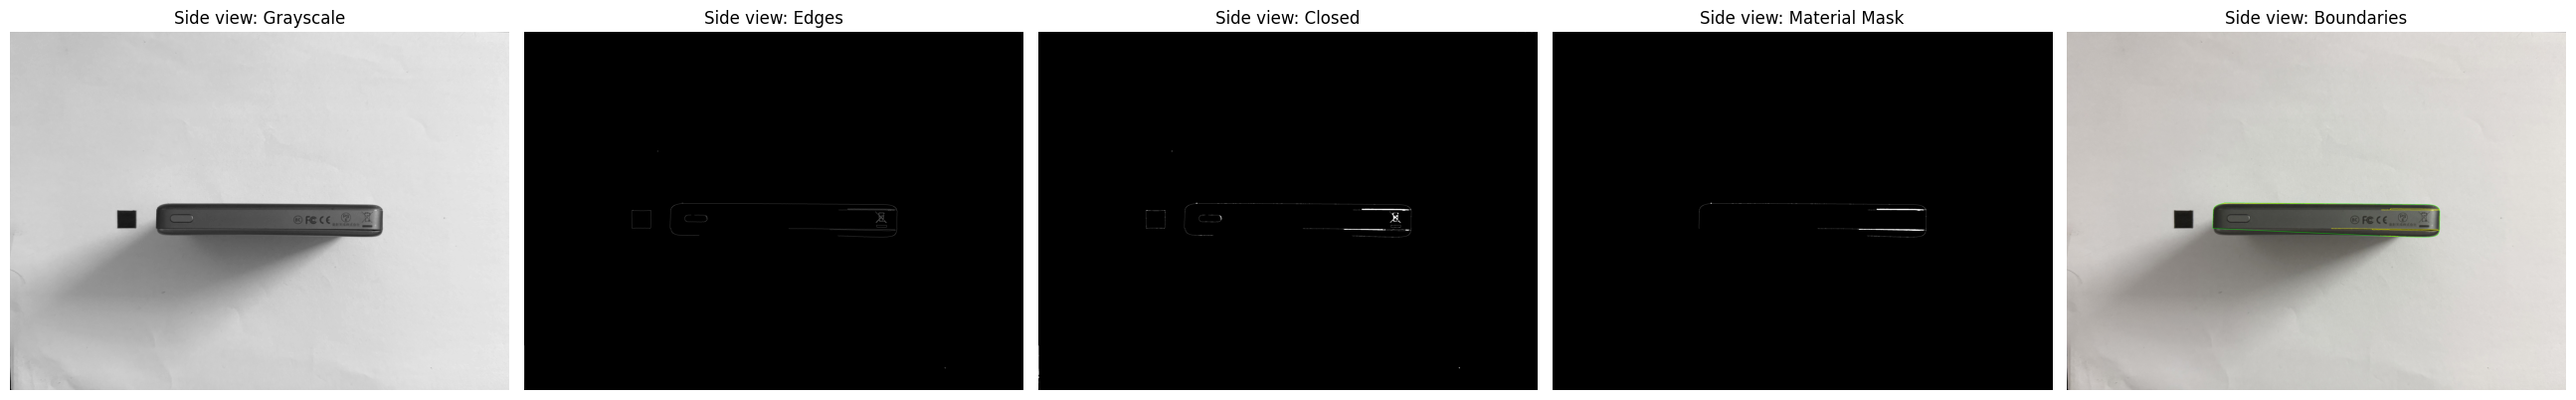

--- Material-aware Measurement Transparency ---
Top material area used:  1383104.0 px^2
Top material area used:  59.0843 cm^2
Side height used:        315 px  |  1.8000 cm
Volume = Area x Height:  106.3517 cm^3


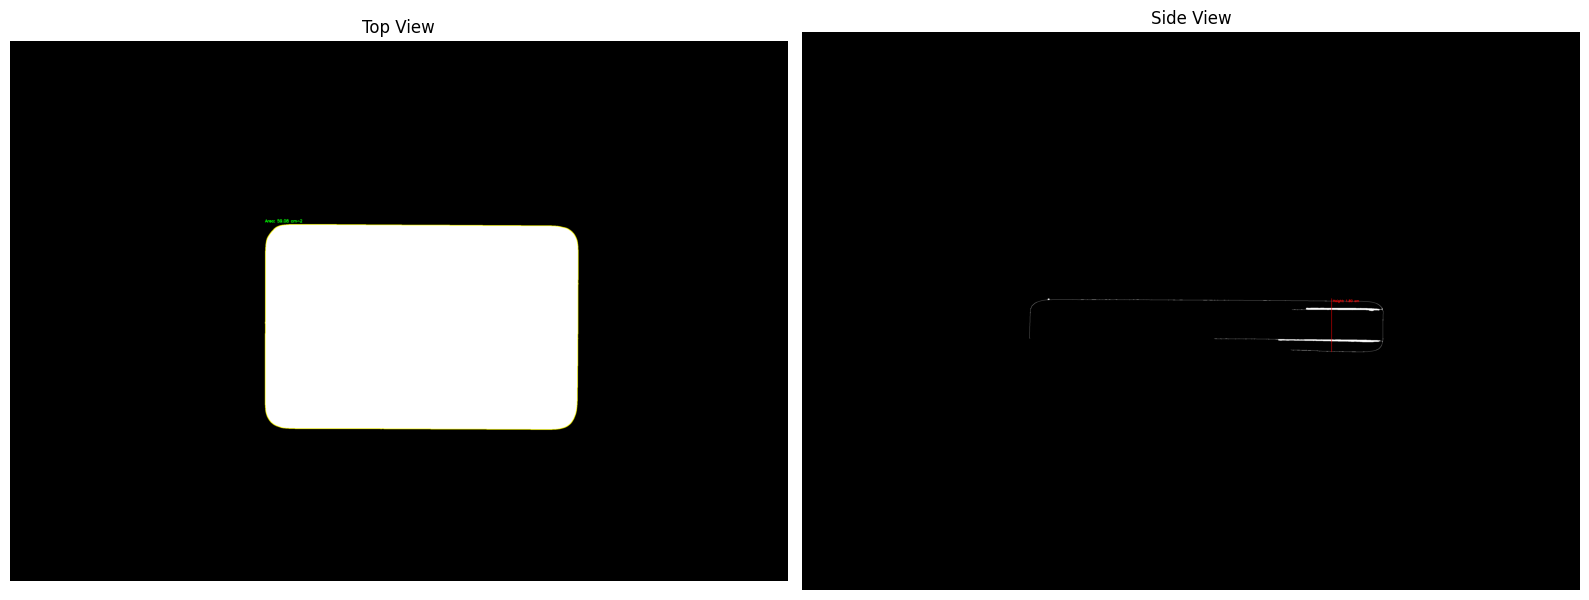

Estimated Volume (cm^3): 106.35171088043062


In [ ]:
top_seg = segment_object(
    top_view,
    view_name="Top view",
    debug=True,
    ref_square_size_px=top_ref_size_px,
    bg_similarity=0.75,
    close_iterations=2
    )

side_seg = segment_object(
    side_view,
    view_name="Side view",
    debug=True,
    ref_square_size_px=side_ref_size_px,
    bg_similarity=0.75,
    close_iterations=2
    )

volume = compute_volume_from_boundaries(
    top_seg=top_seg,
    side_seg=side_seg,
    top_scale_cm=top_scale_cm,
    side_scale_cm=side_scale_cm,
    debug=True
)

print("Estimated Volume (cm^3):", volume)


#### Weight + Density

In [148]:
weight = 2000  # grams

In [149]:
density = weight / volume  # g/cm^3
print(f"Estimated Density: {density:.4f} g/cm^3")

Estimated Density: 18.8055 g/cm^3


#### Purity Analysis

In [150]:
def density_to_karat_formula(D):
    """Convert density (g/cm³) to estimated karat using the fitted polynomial."""
    return 0.0089 * D**3 - 0.550 * D**2 + 12.5299 * D - 77.06


karat_density_ranges = {
    24: (19.31, 19.51),
    22: (17.45, 18.24),
    20: (16.03, 17.11),
    18: (14.84, 16.12),
    14: (12.91, 14.44),
    10: (11.42, 13.09),
}

karat_from_formula = density_to_karat_formula(density)

print("=" * 60)
print("PURITY ANALYSIS RESULTS")
print("=" * 60)
print(f"\nMeasured Density: {density:.4f} g/cm³")
print("\nMethod 1 - Polynomial Formula:")
print(f"  Estimated Karat: {karat_from_formula:.2f}K")

print("\nMethod 2 - Density Range Classification:")
found_match = False
for karat, (min_d, max_d) in sorted(karat_density_ranges.items(), reverse=True):
    if min_d <= density <= max_d:
        print(f"  ✓ Matches K{karat} range ({min_d} - {max_d} g/cm³)")
        found_match = True
        break

if not found_match:
    closest_karat = None
    min_distance = float('inf')
    for karat, (min_d, max_d) in karat_density_ranges.items():
        mid_d = (min_d + max_d) / 2
        distance = abs(density - mid_d)
        if distance < min_distance:
            min_distance = distance
            closest_karat = karat

    if closest_karat:
        min_d, max_d = karat_density_ranges[closest_karat]
        if density < min_d:
            print(f"  → Below K{closest_karat} range (closest: {min_d} - {max_d} g/cm³)")
        else:
            print(f"  → Above K{closest_karat} range (closest: {min_d} - {max_d} g/cm³)")

print("=" * 60)

PURITY ANALYSIS RESULTS

Measured Density: 18.8055 g/cm³

Method 1 - Polynomial Formula:
  Estimated Karat: 23.25K

Method 2 - Density Range Classification:
  → Below K24 range (closest: 19.31 - 19.51 g/cm³)


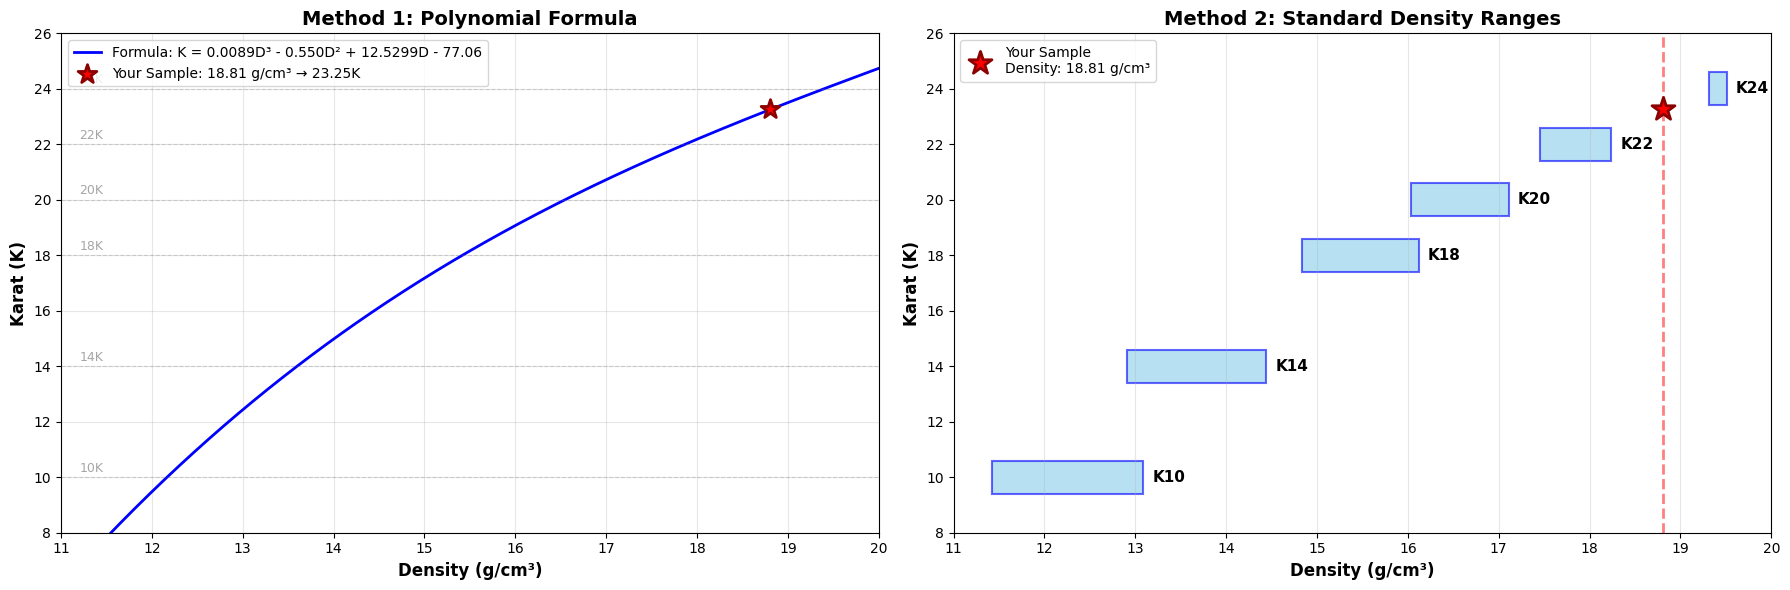


📊 Visualization complete! Both methods are displayed above.


In [151]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Polynomial Formula Curve
densities_range = np.linspace(11, 20, 500)
karats_formula = [density_to_karat_formula(d) for d in densities_range]

ax1.plot(densities_range, karats_formula, 'b-', linewidth=2, label='Formula: K = 0.0089D³ - 0.550D² + 12.5299D - 77.06')
ax1.scatter([density], [karat_from_formula], color='red', s=200, zorder=5, marker='*', 
            edgecolors='darkred', linewidth=2, label=f'Your Sample: {density:.2f} g/cm³ → {karat_from_formula:.2f}K')

# Add horizontal lines for standard karats
for k in [10, 14, 18, 20, 22, 24]:
    ax1.axhline(y=k, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
    ax1.text(11.2, k + 0.2, f'{k}K', fontsize=9, color='gray', alpha=0.7)

ax1.set_xlabel('Density (g/cm³)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Karat (K)', fontsize=12, fontweight='bold')
ax1.set_title('Method 1: Polynomial Formula', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=10)
ax1.set_xlim(11, 20)
ax1.set_ylim(8, 26)

# Plot 2: Density Range Classification
karat_values = sorted(karat_density_ranges.keys())
min_densities = [karat_density_ranges[k][0] for k in karat_values]
max_densities = [karat_density_ranges[k][1] for k in karat_values]
mid_densities = [(karat_density_ranges[k][0] + karat_density_ranges[k][1]) / 2 for k in karat_values]

# Plot density ranges as horizontal bars
for i, karat in enumerate(karat_values):
    min_d, max_d = karat_density_ranges[karat]
    ax2.barh(karat, max_d - min_d, left=min_d, height=1.2, 
             alpha=0.6, color='skyblue', edgecolor='blue', linewidth=1.5)
    ax2.text(max_d + 0.1, karat, f'K{karat}', fontsize=11, va='center', fontweight='bold')

# Plot sample point
ax2.scatter([density], [karat_from_formula], color='red', s=300, zorder=5, marker='*',
            edgecolors='darkred', linewidth=2, label=f'Your Sample\nDensity: {density:.2f} g/cm³')

# Add vertical line for sample density
ax2.axvline(x=density, color='red', linestyle='--', alpha=0.5, linewidth=2)

ax2.set_xlabel('Density (g/cm³)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Karat (K)', fontsize=12, fontweight='bold')
ax2.set_title('Method 2: Standard Density Ranges', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
ax2.legend(loc='best', fontsize=10)
ax2.set_xlim(11, 20)
ax2.set_ylim(8, 26)

plt.tight_layout()
plt.show()

print("\n📊 Visualization complete! Both methods are displayed above.")